# Gráficos de inclinação (*slope charts*)
Desemprego por região do Brasil: 2018 × 2025

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Identidade visual da disciplina: base cinza/grafite com acento laranja
CINZA_ESCURO = "#3A3A3A"   # textos
CINZA_MEDIO  = "#8C8C8C"   # 2018 / séries de contexto
CINZA_CLARO  = "#D9D9D9"   # grade
LARANJA      = "#E8702A"   # 2025 / destaque

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Calibri", "Carlito", "DejaVu Sans"],
    "font.size": 12,
    "text.color": CINZA_ESCURO,
    "axes.labelcolor": CINZA_ESCURO,
    "xtick.color": CINZA_ESCURO,
    "ytick.color": CINZA_ESCURO,
    "figure.dpi": 110,
})

def br(v, casas=1):
    """Formata número com vírgula decimal."""
    return f"{v:.{casas}f}".replace(".", ",")

## Leitura dos dados
O arquivo está em **UTF-16** e separado por **tabulação**. O cabeçalho tem
5 campos, mas as linhas de dados têm 6 (uma tabulação vazia a mais), por isso
as três colunas úteis são lidas por posição.

In [2]:
ARQUIVO = "desemprego_por_regiao_2018_2025.csv"

df = pd.read_csv(
    ARQUIVO, sep="\t", encoding="utf-16",
    header=None, skiprows=1, usecols=[0, 1, 2],
    names=["ano", "regiao", "taxa"],
)

ANO_INI, ANO_FIM = 2018, 2025
tab = (df[df["ano"].isin([ANO_INI, ANO_FIM])]
       .pivot(index="regiao", columns="ano", values="taxa")
       .sort_values(ANO_INI, ascending=False))   # ordena pelo valor inicial
tab["variacao"] = tab[ANO_FIM] - tab[ANO_INI]
tab

ano,2018,2025,variacao
regiao,,,
Nordeste,14.6,7.9,-6.7
Sudeste,12.8,5.3,-7.5
Norte,12.4,6.6,-5.8
Centro-Oeste,9.3,4.4,-4.9
Sul,7.8,3.4,-4.4


## 1. Colunas pareadas

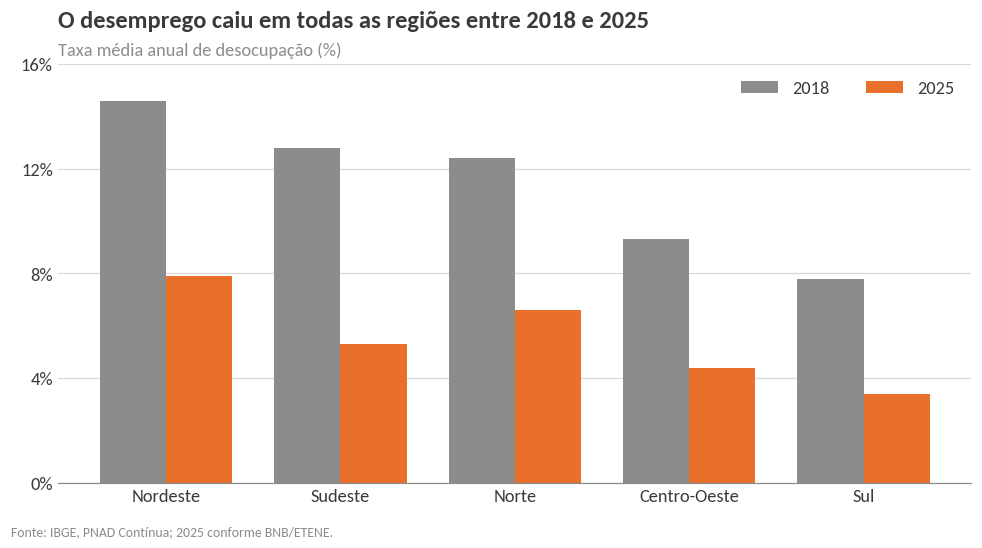

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

x = range(len(tab))
larg = 0.38
ax.bar([i - larg/2 for i in x], tab[ANO_INI], width=larg,
       color=CINZA_MEDIO, label=str(ANO_INI))
ax.bar([i + larg/2 for i in x], tab[ANO_FIM], width=larg,
       color=LARANJA, label=str(ANO_FIM))

# Grade horizontal ATRÁS das colunas
ax.set_axisbelow(True)
ax.yaxis.grid(True, color=CINZA_CLARO, linewidth=0.8)
ax.xaxis.grid(False)

ax.set_xticks(list(x))
ax.set_xticklabels(tab.index)
ax.set_ylim(0, 16)
ax.yaxis.set_major_locator(mticker.MultipleLocator(4))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.tick_params(length=0)
for lado in ["top", "right", "left"]:
    ax.spines[lado].set_visible(False)
ax.spines["bottom"].set_color(CINZA_MEDIO)

ax.legend(frameon=False, ncols=2, loc="upper right")
ax.set_title("O desemprego caiu em todas as regiões entre 2018 e 2025",
             loc="left", fontsize=16, fontweight="bold", pad=24)
ax.text(0, 1.02, "Taxa média anual de desocupação (%)",
        transform=ax.transAxes, fontsize=12, color=CINZA_MEDIO)
fig.text(0.01, 0.01, "Fonte: IBGE, PNAD Contínua; 2025 conforme BNB/ETENE.",
         fontsize=9, color=CINZA_MEDIO)

fig.tight_layout(rect=(0, 0.03, 1, 1))
# fig.savefig("colunas_pareadas_desemprego.png", dpi=200, bbox_inches="tight")
plt.show()

## 2. Gráfico de inclinação

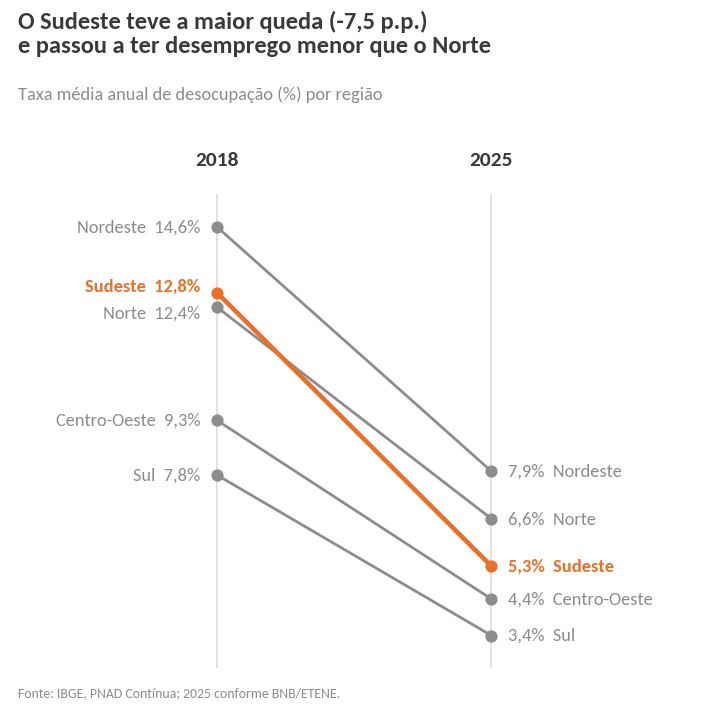

In [4]:
def espalhar(valores, dist_min):
    """Afasta verticalmente rótulos que ficariam sobrepostos,
    preservando a ordem original. Retorna as posições ajustadas."""
    ordem = sorted(range(len(valores)), key=lambda i: valores[i])
    pos = list(valores)
    for _ in range(50):                      # algumas iterações bastam
        mudou = False
        for a, b in zip(ordem, ordem[1:]):
            falta = dist_min - (pos[b] - pos[a])
            if falta > 0:
                pos[a] -= falta / 2
                pos[b] += falta / 2
                mudou = True
        if not mudou:
            break
    return pos

DESTAQUE = "Sudeste"      # região com a maior queda absoluta

fig, ax = plt.subplots(figsize=(6.5, 6.5))
X0, X1 = 0, 1

regioes = list(tab.index)
v0, v1 = tab[ANO_INI].tolist(), tab[ANO_FIM].tolist()
y0_rot, y1_rot = espalhar(v0, 0.75), espalhar(v1, 0.75)

for i, reg in enumerate(regioes):
    cor = LARANJA if reg == DESTAQUE else CINZA_MEDIO
    esp = 3.0 if reg == DESTAQUE else 1.8
    z = 3 if reg == DESTAQUE else 2
    peso = "bold" if reg == DESTAQUE else "normal"

    ax.plot([X0, X1], [v0[i], v1[i]], color=cor, linewidth=esp, zorder=z,
            marker="o", markersize=7, solid_capstyle="round")

    # Rótulos diretos (dispensam legenda e eixo y)
    ax.text(X0 - 0.06, y0_rot[i], f"{reg}  {br(v0[i])}%",
            ha="right", va="center", color=cor, fontweight=peso)
    ax.text(X1 + 0.06, y1_rot[i], f"{br(v1[i])}%  {reg}",
            ha="left", va="center", color=cor, fontweight=peso)

# Cabeçalhos dos "eixos" verticais
for xp, ano in [(X0, ANO_INI), (X1, ANO_FIM)]:
    ax.vlines(xp, 2.5, 15.5, color=CINZA_CLARO, linewidth=1, zorder=1)
    ax.text(xp, 16.2, str(ano), ha="center", va="bottom",
            fontsize=14, fontweight="bold")

ax.set_xlim(-0.75, 1.75)
ax.set_ylim(2.5, 17)
ax.axis("off")

dv = tab.loc[DESTAQUE, "variacao"]
fig.suptitle(f"O {DESTAQUE} teve a maior queda ({br(dv)} p.p.)\n"
             "e passou a ter desemprego menor que o Norte",
             x=0.03, ha="left", fontsize=16, fontweight="bold")
fig.text(0.03, 0.855, "Taxa média anual de desocupação (%) por região",
         fontsize=12, color=CINZA_MEDIO)
fig.text(0.03, 0.02, "Fonte: IBGE, PNAD Contínua; 2025 conforme BNB/ETENE.",
         fontsize=9, color=CINZA_MEDIO)

fig.subplots_adjust(top=0.80, bottom=0.06, left=0.02, right=0.98)
# fig.savefig("inclinacao_desemprego.png", dpi=200, bbox_inches="tight")
plt.show()